# Online Retail - Customer Churn
## Dataset
This dataset comes from the UCI Machine Learning Repository it is the Online Retail dataset and contains transactional data for a UK based online retailer who mainly sell "unique all-occassion gifts". A lot of customers are wholesale businesses.

## Problem Statement
Can I build a predictive model to identify customers that are likely to churn so we can take pro-active measures to retain business and increase revenue?

### Importing the dataset

In [25]:
from ucimlrepo import fetch_ucirepo 
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
data = online_retail.data.original 

### Exploratory Analysis

In [ ]:
data.info()

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [17]:
data.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

There are 4372 unqique customers to make predictions

In [18]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Investigating Outliers
Max and min quantity of 81,000 looks incorrect will need to investigate the outlier

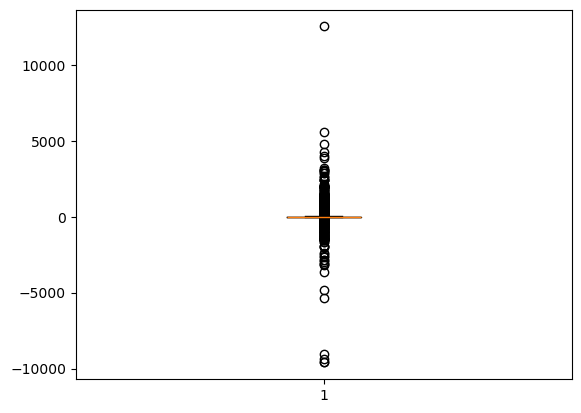

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,12/2/2010 14:23,0.03,15838.0,United Kingdom
225528,556687,23003,Printing smudges/thrown away,-9058,6/14/2011 10:36,0.00,NaN,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,6/14/2011 10:37,0.00,NaN,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,6/14/2011 10:37,0.00,NaN,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,11/25/2011 15:57,0.00,13256.0,United Kingdom


In [45]:
plt.boxplot(data['Quantity'])
plt.show()

outliers = data[data['Quantity'].abs() > 8000]
outliers

Consdiering the extremely high outlier values and the matching cancelled transaction, this is likely a customer adding an extra 0 to their order, because this does not represent genuine customer behaviour it should be removed from the dataset. The value of 8000 was selected due to there being additional extreme outliers that did not reflect genuine customer behaviour

## Feature Engineering
Creating features to train a classification model to predict customer churn. Customer churn is defined as not placing an order within the next snapshot which is 60 days. Whilst some customers may have a buying frequency that is greater than 60 days, this captures the majority of customer behaviour. SQL is used here due to its convenience for data manipulation and to demonstrate technical capability

In [48]:
# SQL query to group data by bi monthly snapshots and customer id
df = duckdb.sql(
'''
WITH RECURSIVE online_retail AS (
    SELECT
        b.Country                                                   AS country,
        b.Description                                               AS description,
        b.Quantity                                                  AS quantity,
        CAST(STRPTIME(b.InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)     AS invoice_date,
        MIN(invoice_date) OVER(PARTITION BY CustomerID)             AS first_purchase_date,
        b.UnitPrice                                                 AS unit_price,
        CAST(b.CustomerID AS STRING)                                AS customer_id,
        b.InvoiceNo                                                 AS invoice_number,
        b.Quantity * b.UnitPrice                                    AS order_value
    FROM
        data b
    WHERE 
        customer_id IS NOT NULL
),

snapshots AS (
    -- Anchor member - first date in dataset: 1/10/2010
    SELECT
        MIN(invoice_date) AS snapshot,
        MAX(invoice_date) AS max_date
    FROM 
        online_retail

    UNION ALL

    -- Recursive Member
    SELECT
        DATE_ADD(snapshot, INTERVAL 2 MONTH) AS snapshot,
        max_date
    FROM 
        snapshots
    WHERE
        DATE_ADD(snapshot, INTERVAL 2 MONTH) <= max_date
),

customer_snapshots AS (
    SELECT 
        s.snapshot,
        c.customer_id
    FROM 
        snapshots s
    CROSS JOIN 
        (SELECT DISTINCT customer_id FROM online_retail) c
),

cleaned_transactions AS (
    SELECT
        customer_id,
        invoice_number,
        invoice_date,
        description,
        order_value,
        quantity,
        MIN(invoice_date) OVER(PARTITION BY customer_id) AS first_purchase_date,
        CASE WHEN description = 'Discount' THEN 1 ELSE 0 END AS is_discount,
        CASE WHEN description = 'Discount' THEN order_value * -1 ELSE 0 END AS discount_value,
        CASE WHEN quantity < 0 THEN 1 ELSE 0 END AS is_return,
        CASE WHEN quantity < 0 THEN order_value * -1 ELSE 0 END AS returns_value,
        CASE WHEN ASCII(description) = ASCII(UPPER(description)) THEN 1 ELSE 0 END AS is_product
    FROM
        online_retail
),

snapshot_behaviour AS (
    SELECT 
        s.snapshot, 
        s.customer_id,
        SUM(c.order_value)                                                      AS snapshot_order_value,
        COUNT(DISTINCT c.invoice_number)                                        AS snapshot_orders_placed,
        SUM(c.order_value) / COUNT(DISTINCT c.invoice_number)                   AS snapshot_avg_order_value,
        COUNT(DISTINCT CASE WHEN c.is_discount = 1 THEN c.invoice_number END)   AS snapshot_total_discounts,
        COUNT(DISTINCT CASE WHEN c.is_return = 1 THEN c.invoice_number END)     AS snapshot_orders_returned,
        COUNT(DISTINCT CASE WHEN c.is_product = 1 THEN c.description END)       AS snapshot_unique_products_ordered,
        SUM(c.discount_value)                                                   AS snapshot_discount_value,
        SUM(c.returns_value)                                                    AS snapshot_returns_value,
        DATE_DIFF('day', MAX(first_purchase_date), MAX(invoice_date))           AS customer_age
    FROM
        customer_snapshots s
    LEFT JOIN
        cleaned_transactions c 
        ON c.customer_id = s.customer_id
        AND c.invoice_date >= s.snapshot  
        AND c.invoice_date < DATE_ADD(s.snapshot, INTERVAL 2 MONTH) -- Looking at only the current snapshot
    GROUP BY
        s.snapshot,
        s.customer_id
),

customer_history AS (
    SELECT
        s.snapshot, 
        s.customer_id,
        SUM(c.order_value)                                                      AS total_order_value,
        COUNT(DISTINCT c.invoice_number)                                        AS total_orders_placed,
        SUM(c.order_value) / COUNT(DISTINCT c.invoice_number)                   AS historic_avg_order_value,
        COUNT(DISTINCT CASE WHEN c.is_discount = 1 THEN c.invoice_number END)   AS total_discounts,
        COUNT(DISTINCT CASE WHEN c.is_return = 1 THEN c.invoice_number END)     AS total_orders_returned,
        COUNT(DISTINCT CASE WHEN c.is_product = 1 THEN c.description END)       AS unique_products_ordered,
        SUM(c.discount_value)                                                   AS total_discount_value,
        SUM(c.returns_value)                                                    AS total_returns_value
    FROM
        customer_snapshots s
    LEFT JOIN
        cleaned_transactions c
        ON c.customer_id = s.customer_id
        AND c.invoice_date < s.snapshot -- Looking at behaviour in all previous snapshots
    GROUP BY
        s.snapshot,
        s.customer_id
)

SELECT
    COALESCE(a.customer_id, b.customer_id) AS customer_id,
    COALESCE(a.snapshot, b.snapshot) AS snapshot,

    a.total_order_value,
    a.total_orders_placed,
    a.historic_avg_order_value,
    a.total_discounts,
    a.total_orders_returned,
    a.unique_products_ordered,
    a.total_discount_value,
    a.total_returns_value,

    b.snapshot_order_value,
    b.snapshot_orders_placed,
    b.snapshot_avg_order_value,
    b.snapshot_total_discounts,
    b.snapshot_orders_returned,
    b.snapshot_unique_products_ordered,
    b.snapshot_discount_value,
    b.snapshot_returns_value,
    b.customer_age,

-- Churn Flag: 1 if the NEXT snapshot period has ZERO or NULL orders
CASE 
    WHEN COALESCE(LEAD(snapshot_orders_placed, 1) OVER (
        PARTITION BY customer_id 
        ORDER BY snapshot
    ), 0) = 0 THEN 1 
    ELSE 0 
END AS customer_churned
FROM
    customer_history a 
LEFT JOIN
    snapshot_behaviour b USING(snapshot, customer_id)
WHERE
    a.total_order_value >= 0
QUALIFY LAG(snapshot_orders_placed, 1, 1) OVER (
    PARTITION BY customer_id
    ORDER BY snapshot
) > 0
'''
).df()

# Converting NULLS to zero
df = df.fillna(0)

# Ranking snapshots in order
df["snapshot"] = pd.to_datetime(df["snapshot"])
df = df.sort_values(["customer_id", "snapshot"])
rev_rank = df.groupby("customer_id").cumcount(ascending=False)

# Test dataset is the penultimate snapshot of data and train is all previous snapshots
test = df[rev_rank == 1]
train = df[rev_rank >= 1]

features = [
    "total_order_value",
    "total_orders_placed",
    "historic_avg_order_value",
    "total_discounts",
    "total_orders_returned",
    "unique_products_ordered",
    "total_discount_value",
    "total_returns_value",
    "snapshot_order_value",
    "snapshot_orders_placed",
    "snapshot_avg_order_value",
    "snapshot_total_discounts",
    "snapshot_orders_returned",
    "snapshot_unique_products_ordered",
    "snapshot_discount_value",
    "snapshot_returns_value",
    "customer_age"
]

# Converting data frame into n-dimensional numpy arrays
X_train = train[features].to_numpy()
X_test = test[features].to_numpy()

y_train = train['customer_churned']
y_test = test['customer_churned']

print(X_train.shape)
print(X_test.shape)

(5912, 17)
(2502, 17)


# Investigating Features

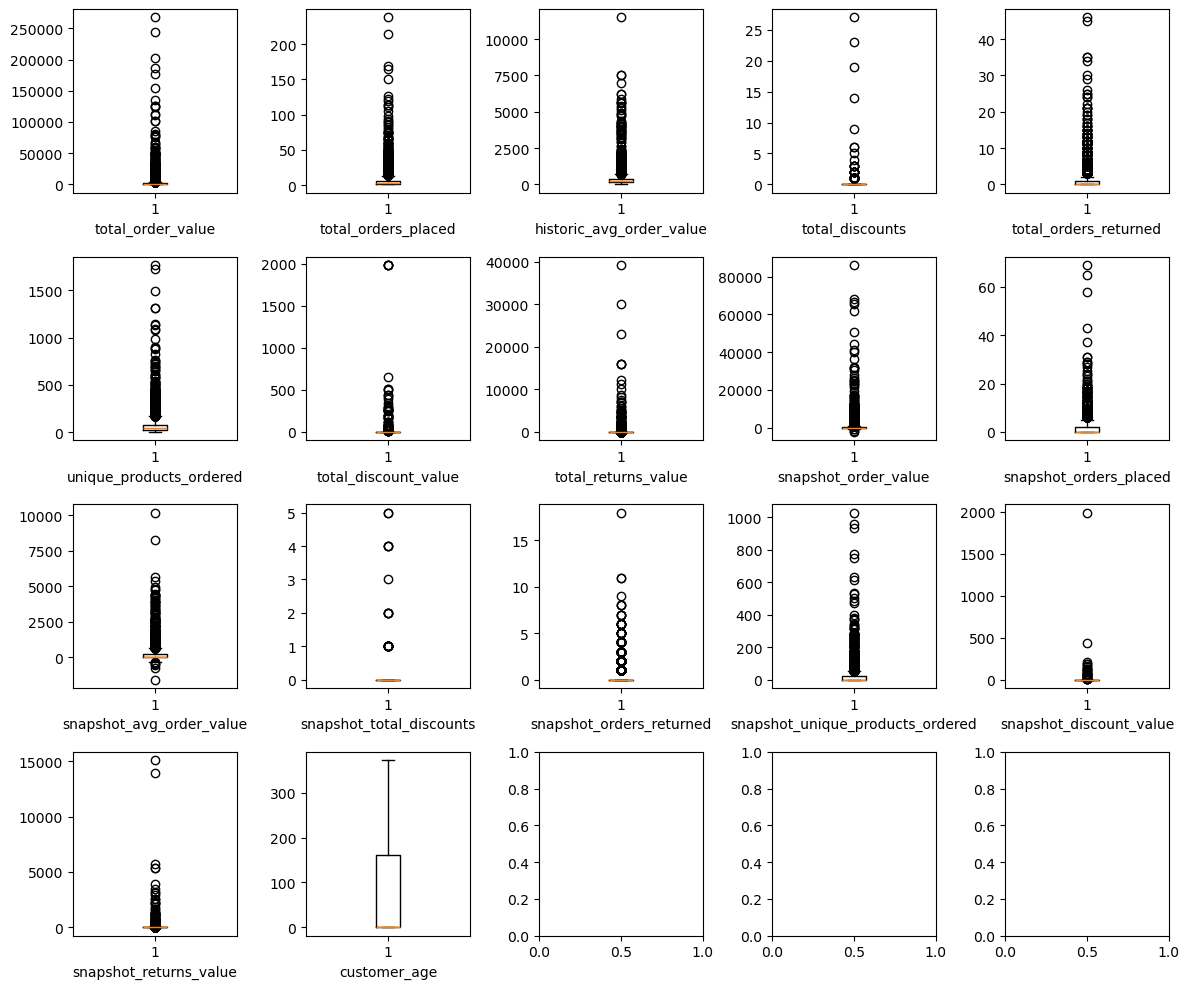

In [49]:
def boxplots(df, features):
    figure, axes = plt.subplots(4, 5, figsize=(12,10))
    axes = axes.flatten()

    i = 0
    for col in features:
        axes[i].boxplot(df[col])
        axes[i].set_xlabel(col)
        i += 1

    plt.tight_layout()
    plt.show()

boxplots(df, features)

## Scatter plots

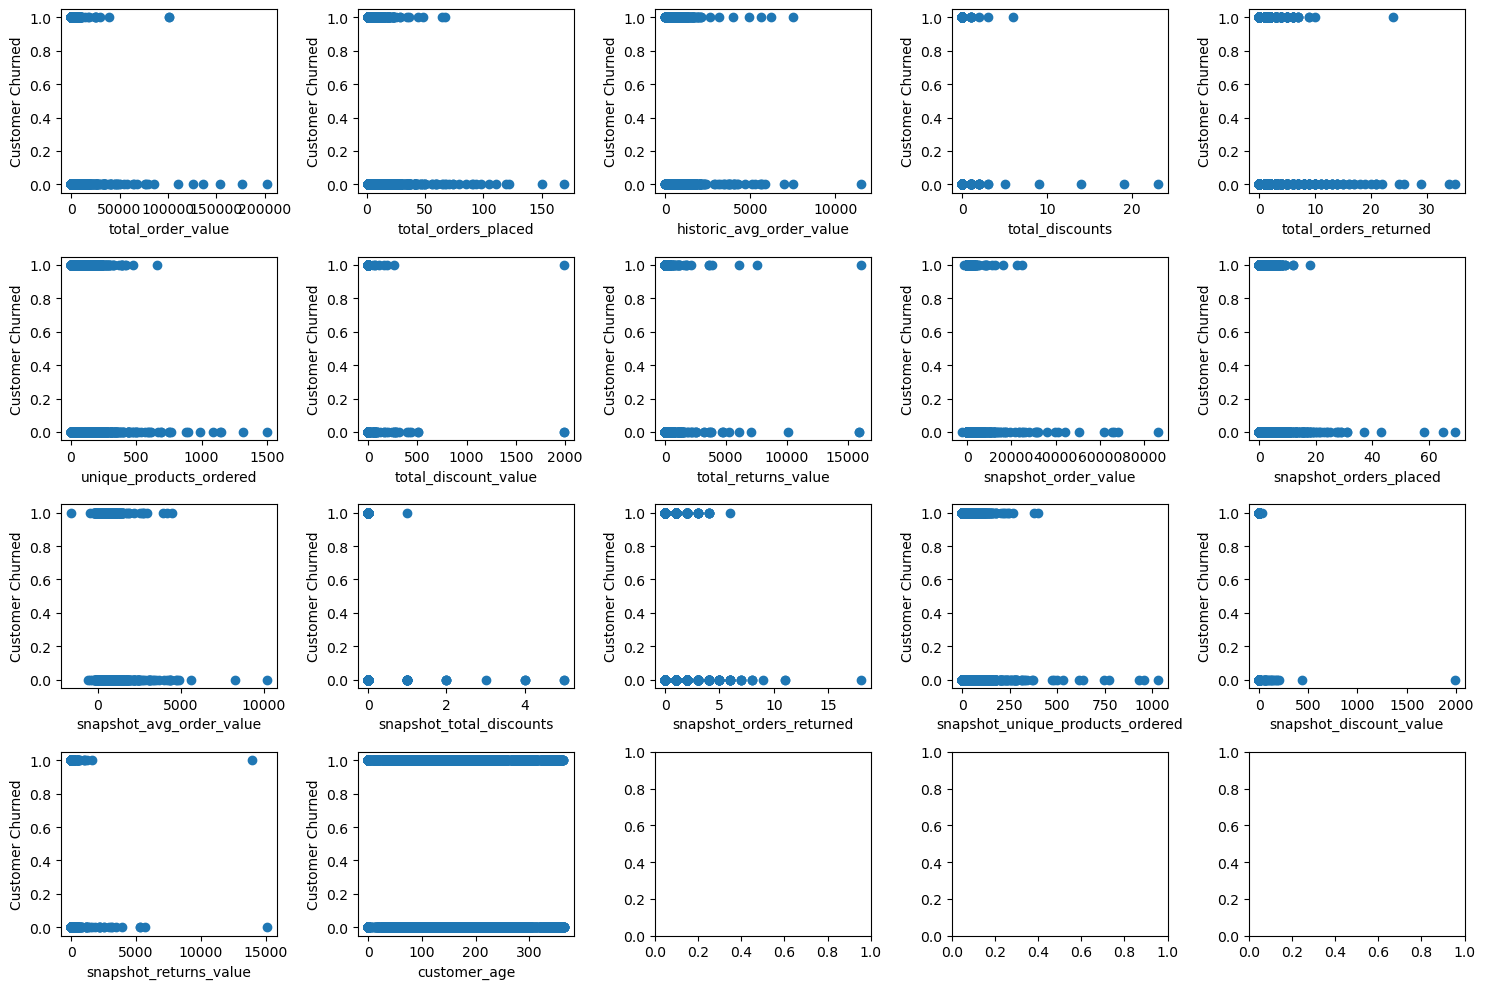

In [50]:
m,n = X_train.shape

figure, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

# Investigating collinearity

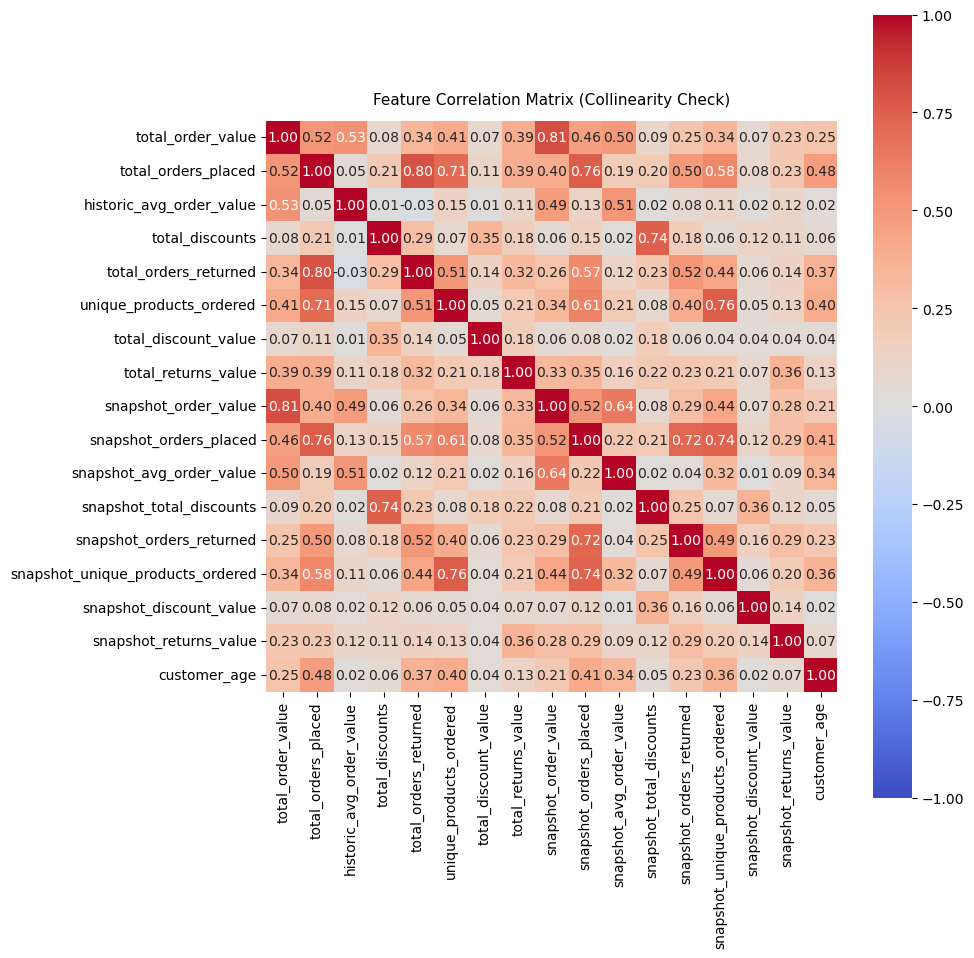

In [53]:
import seaborn as sns

# Convert NumPy array back to a DataFrame using your existing feature names list
X_train_df = pd.DataFrame(X_train, columns=features)

# Calculate the pairwise correlation matrix
corr_matrix = X_train_df.corr()

# Plot the graphical heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display numeric correlation values inside cells
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap="coolwarm",     # Red for strong positive, blue for strong negative correlation
    vmin=-1, vmax=1,     # Fix colorbar scale strictly from -1 to 1
    square=True          # Force cells to remain square-shaped
)

plt.title("Feature Correlation Matrix (Collinearity Check)", fontsize=11, pad=12)
plt.tight_layout()
plt.show()

# Logistic Regression
Using logistic regression as a base model to evaluate model impact, due to the non-linear nature of customer churn I don't expect logistic regression alone to be highly accurate

In [ ]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

# Define functions and model
scaler = StandardScaler()
poly = PolynomialFeatures(degree=3)
model = linear_model.LogisticRegression(max_iter=2000, C=0.1, random_state=42)

def transform(X):
    X_poly = poly.fit_transform(X)
    X_poly_scaled = scaler.fit_transform(X_poly)

    return X_poly_scaled

# Transforming data
X_train_poly = transform(X_train)

# Training the model
model.fit(X_train_poly, y_train)

def evaluate(y, y_pred, y_proba):
    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = axes.flatten()

    print(f'Accuracy: {accuracy_score(y, y_pred)}')

    # Confusion Matrix
    matrix = confusion_matrix(y, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, 
                                        display_labels= ['Negative 0', 'Positive 1'])
    cm_display.plot(ax=axes[0], colorbar=False)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    roc_display.plot(ax=axes[1])

    # Precision Recall
    precision, recall, thresholds = precision_recall_curve(y, y_proba)
    pr_auc = auc(recall, precision)
    pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)
    pr_display.plot(ax=axes[2])

    plt.tight_layout()
    plt.show()

# Predicitions
y_pred_poly = model.predict(X_train_poly)
y_pred_poly_proba = model.predict_proba(X_train_poly)[:, 1]

Accuracy: 0.41446842525979216


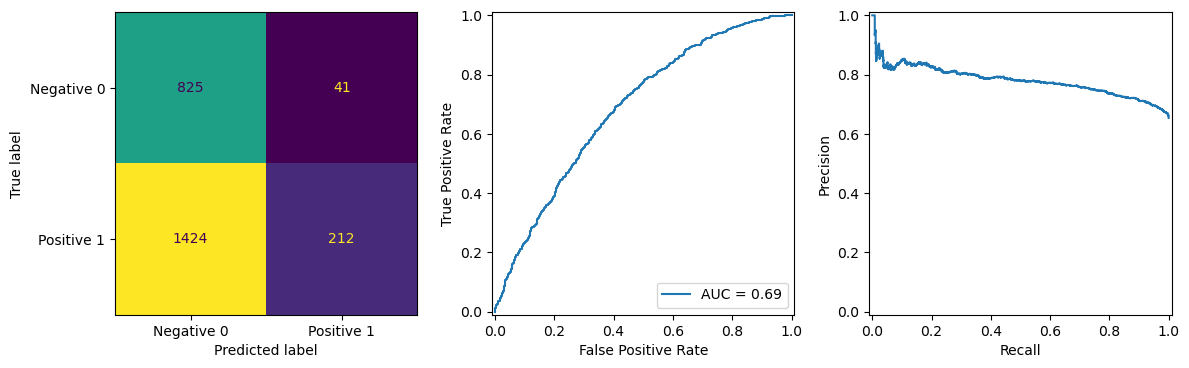

In [68]:
# Transforming test data
X_test_poly = poly.fit_transform(X_test)
X_test_poly = scaler.fit_transform(X_test_poly)
y_pred_poly = model.predict(X_test_poly)
y_proba = model.predict_proba(X_test_poly)[:, 1]

# Evaluating model performance
evaluate(y_test, y_pred_poly, y_proba)

# XGBoost Model
Using a gradient boosted tree model to improve accuracy by capturing non-linear relationships. boosted models have been shown to outperform standard decision trees

c:\Users\josef\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:45:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "feature_names" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7383288227334236


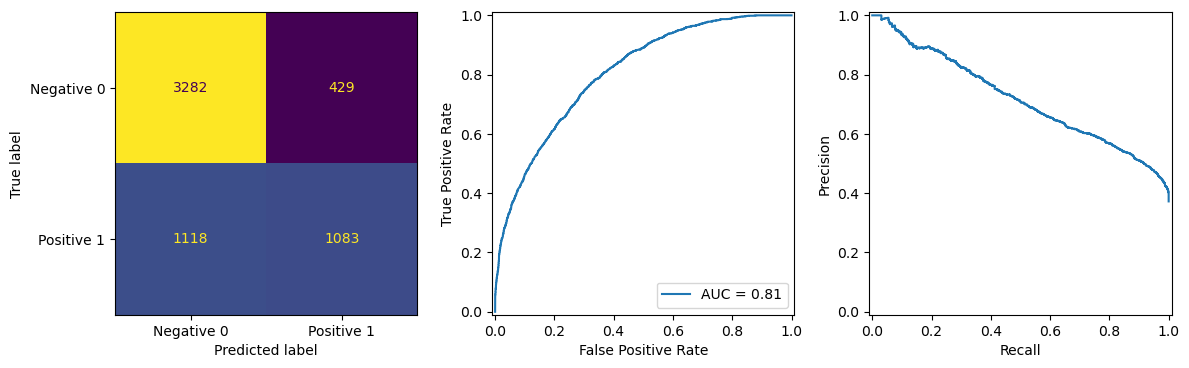

Accuracy: 0.6306954436450839


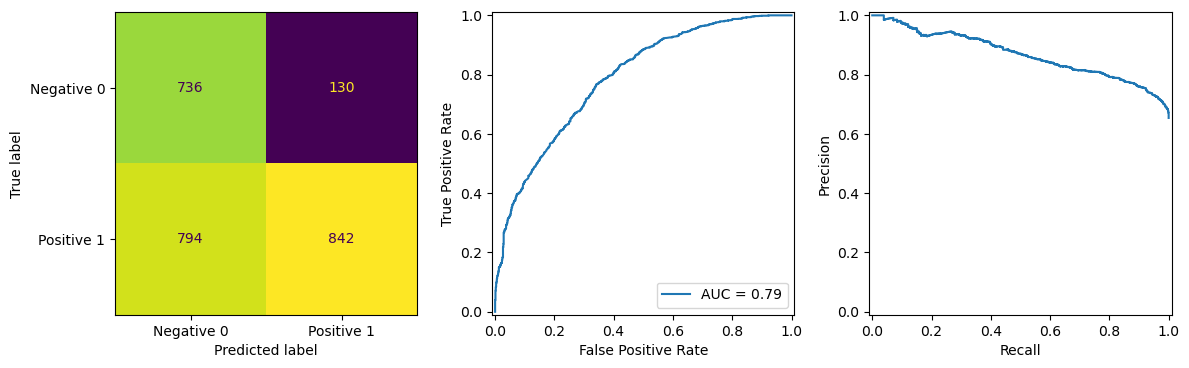

In [ ]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators = 100, 
    max_depth = 4,
    learning_rate = 0.1,
    random_state = 42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_train)
y_proba = model.predict_proba(X_train)[:,1]

evaluate(y_train, y_pred, y_proba)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

evaluate(y_test, y_pred, y_proba)

When predicting the postitive class (customer has churned) the model is highly accurate, Precision=87%. However the low accuracy is a result of a high number of false negatives. The accuracy of the model could be improved by lowering the decision boundary as the precision only suffers small decrease when recall is increased. 

In the training data actual churn sat around 38%, whereas in the test data actual churn sits around 65%. I believe this could be a seasonal trend as the test snapshot is October to December near the UK Christmas holidays. Unfortunately due to the time horizon of the data, we are unable to capture seasonal trends which could help improve model performance.

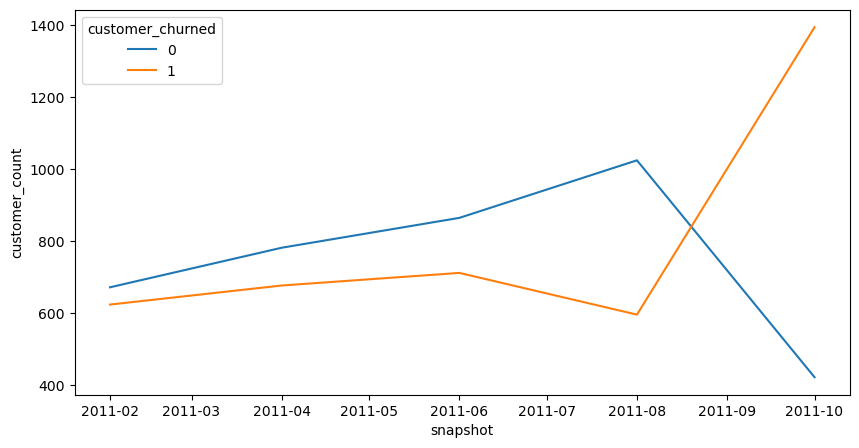

In [ ]:
# Creating table to show customer churn over time
trend = df.groupby(['snapshot', 'customer_churned'])['customer_id'].nunique().reset_index(name='customer_count')
trend = trend[trend['snapshot'] < trend['snapshot'].max()] # Removing the last snapshot as we don't know customer churn

plt.figure(figsize=(10,5))

sns.lineplot(
    data=trend,
    x='snapshot',
    y='customer_count',
    hue='customer_churned'
)

plt.show()